In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from datasets import load_dataset
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [7]:
dataset = load_dataset("sms_spam")

df = dataset['train'].to_pandas()

df.rename(columns={"sms":"message"}, inplace=True)

df.head()

,message,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [8]:
df.info()

df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5574 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  5574 non-null   object
 1   label    5574 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 87.2+ KB


label
0    4827
1     747
Name: count, dtype: int64

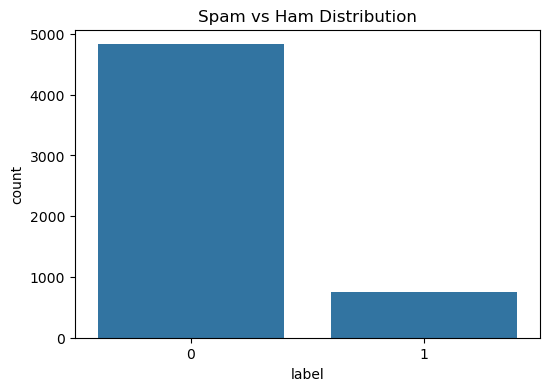

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")

plt.savefig("../results/class_distribution.png")

plt.show()

In [10]:
def clean_text(text):

    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z ]', '', text)

    return text

df['clean_message'] = df['message'].apply(clean_text)

df.head()

,message,label,clean_message
0,"Go until jurong point, crazy.. Available only ...",0,go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...\n,0,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,free entry in a wkly comp to win fa cup final...
3,U dun say so early hor... U c already then say...,0,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",0,nah i dont think he goes to usf he lives aroun...


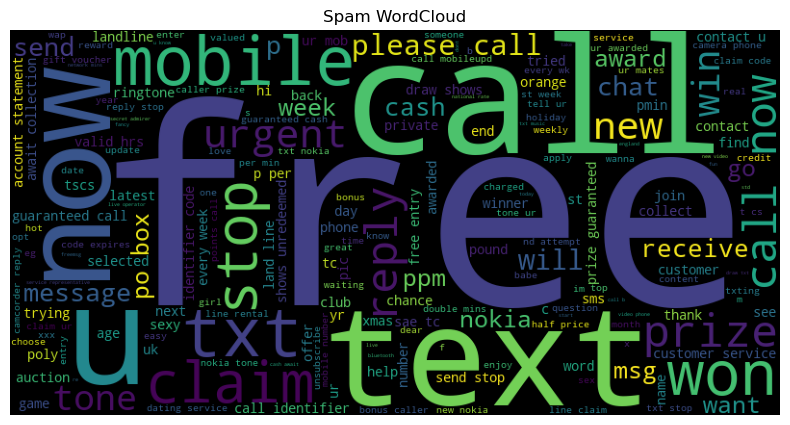

In [12]:
spam_words = " ".join(df[df['label']==1]['clean_message'])

wordcloud = WordCloud(width=800, height=400).generate(spam_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam WordCloud")

plt.savefig("../results/wordcloud_spam.png")

plt.show()

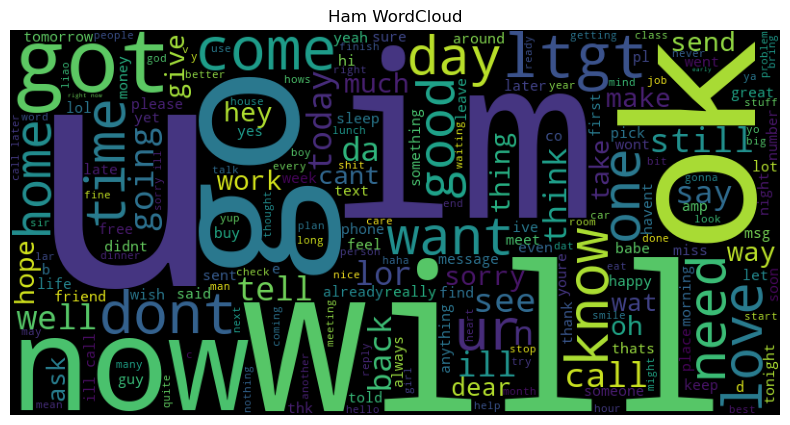

In [13]:
ham_words = " ".join(df[df['label']==0]['clean_message'])

wordcloud = WordCloud(width=800, height=400).generate(ham_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham WordCloud")

plt.savefig("../results/wordcloud_ham.png")

plt.show()

In [14]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['clean_message'])

sequences = tokenizer.texts_to_sequences(df['clean_message'])

In [15]:
X = pad_sequences(sequences, maxlen=100)

y = df['label']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [17]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=100))

model.add(LSTM(64))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

model.compile(

    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']

)

model.summary()

C:\Users\rajar\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(

    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2

)

Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.9992 - loss: 0.0034 - val_accuracy: 0.9753 - val_loss: 0.1062
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9787 - val_loss: 0.1369
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9997 - loss: 8.7312e-04 - val_accuracy: 0.9742 - val_loss: 0.1620
Epoch 4/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9997 - loss: 5.7791e-04 - val_accuracy: 0.9753 - val_loss: 0.1454
Epoch 5/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 1.0000 - loss: 4.8900e-04 - val_accuracy: 0.9753 - val_loss: 0.1727


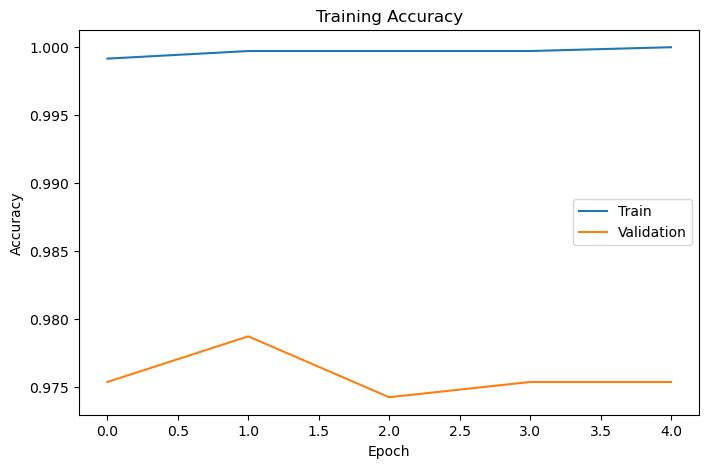

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.savefig("../results/training_curve.png")

plt.show()

In [21]:
pred = model.predict(X_test)

pred = (pred > 0.5)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


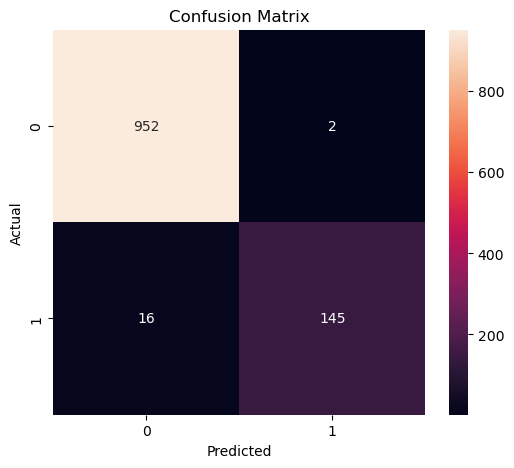

In [22]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("../results/confusion_matrix.png")

plt.show()

In [23]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       954
           1       0.99      0.90      0.94       161

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.97      1115
weighted avg       0.98      0.98      0.98      1115

